# Reliability Engineering Example 2.5

A simplified form of the bathtub curve is based upon the linear and constant hazard/failure rate as follows:

\begin{equation}
\lambda(t)=
\begin{cases}
    c_0 - c_1 t + \lambda, & 0 \le t \le c_0/c_1 \\
    \lambda, & c_0/c_1 \le t \le t_0 \\
    c_2 (t - t_0) + \lambda, & t_0 \le t
\end{cases}
\end{equation}

where $c_0$, $c_1$, $c_2$ and $t_0$ are constant to be determined. Find the reliability function.

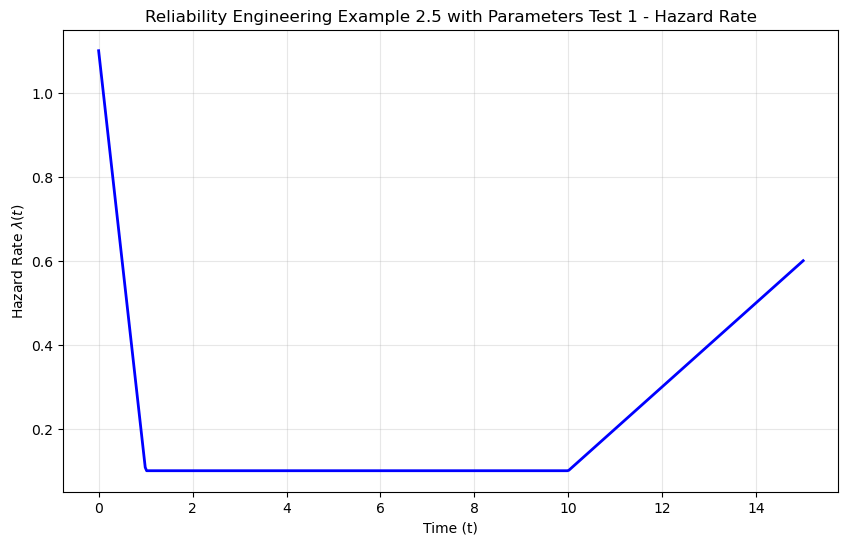

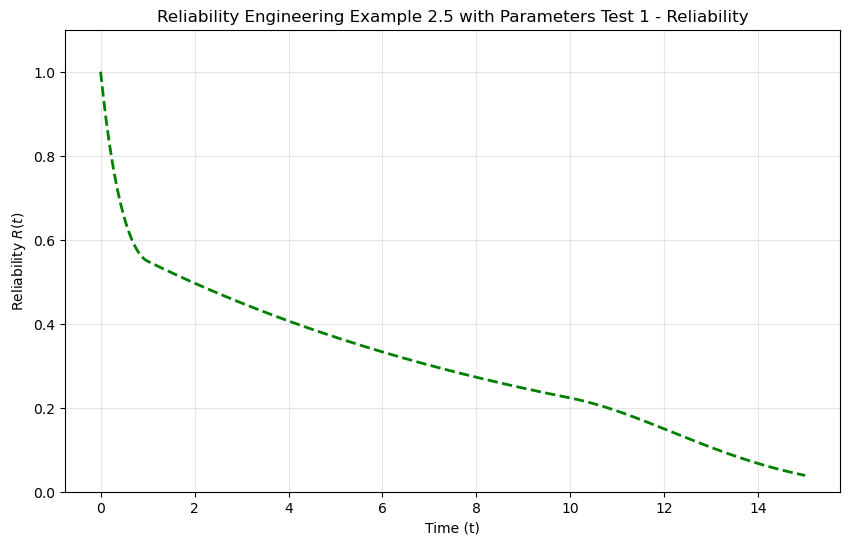

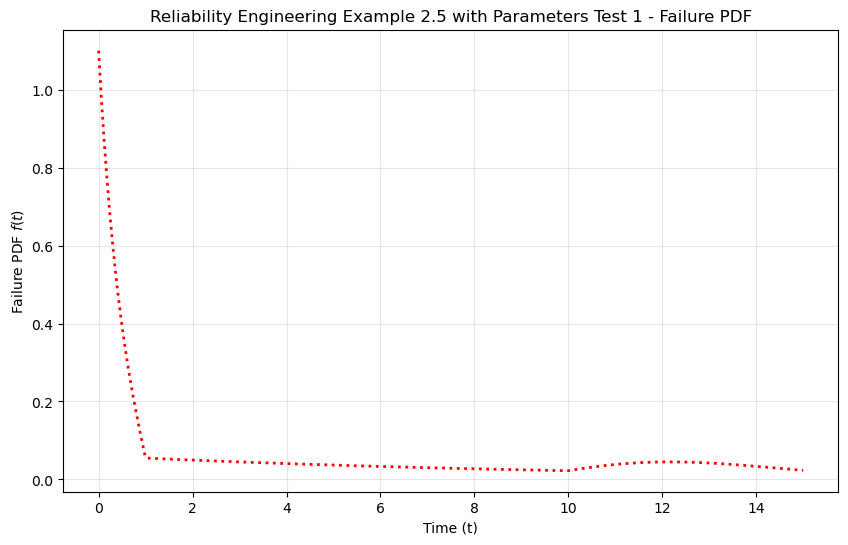

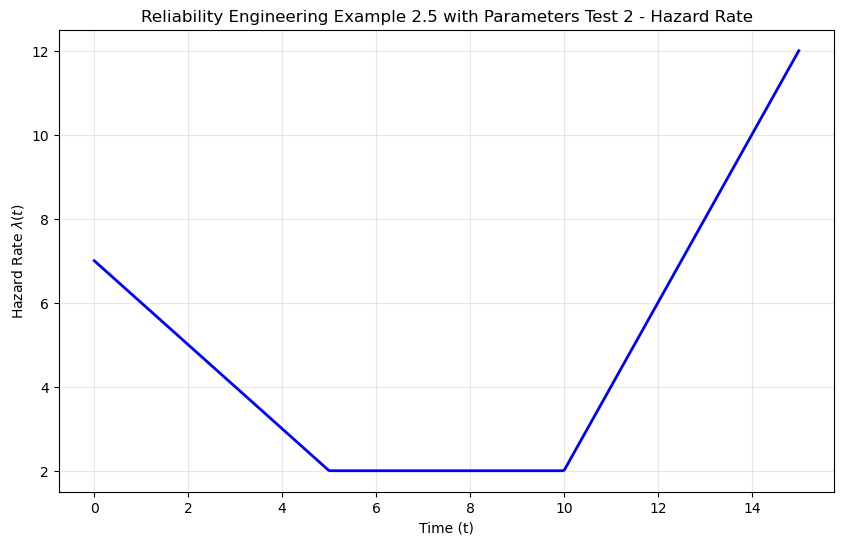

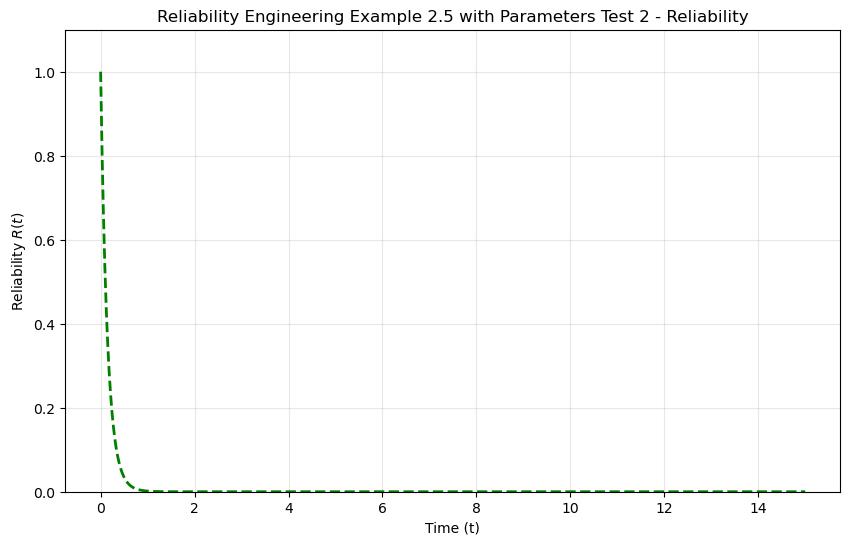

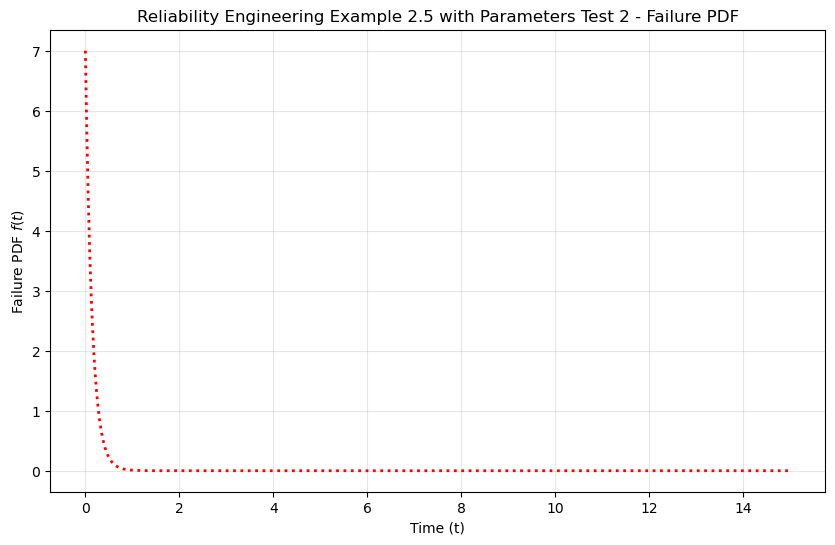

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def get_metrics(t, c0, c1, c2, lam, t0):
    t1 = c0 / c1

    H_t1 = (c0 + lam) * t1 - 0.5 * c1 * (t1**2)
    H_t0 = H_t1 + lam * (t0 - t1)

    if t < 0:
        lt, H = 0, 0
    elif t <= t1:
        lt = c0 - c1 * t + lam
        H = (c0 + lam) * t - 0.5 * c1 * (t**2)
    elif t <= t0:
        lt = lam
        H = H_t1 + lam * (t - t1)
    else:
        lt = c2 * (t - t0) + lam
        H = H_t0 + lam * (t - t0) + 0.5 * c2 * (t - t0)**2
    
    rt = np.exp(-H)
    ft = lt * rt
    return lt, rt, ft

def experiment(c0, c1, c2, lam, t0, title):
    time_series = np.linspace(0, 15, 500)
    results = np.array([get_metrics(t, c0, c1, c2, lam, t0) for t in time_series])
    lt_vals, rt_vals, ft_vals = results[:, 0], results[:, 1], results[:, 2]

    # First figure: Hazard Rate
    plt.figure(figsize=(10, 6))
    plt.plot(time_series, lt_vals, 'b-', lw=2)
    plt.xlabel('Time (t)')
    plt.ylabel(r'Hazard Rate $\lambda(t)$')
    plt.title('Reliability Engineering Example 2.5 with Parameters '+title + ' - Hazard Rate')
    plt.grid(True, alpha=0.3)
    plt.show()

    # Second figure: Reliability
    plt.figure(figsize=(10, 6))
    plt.plot(time_series, rt_vals, 'g--', lw=2)
    plt.xlabel('Time (t)')
    plt.ylabel('Reliability $R(t)$')
    plt.title('Reliability Engineering Example 2.5 with Parameters '+title + ' - Reliability')
    plt.ylim(0, 1.1)
    plt.grid(True, alpha=0.3)
    plt.show()

    # Third figure: Failure PDF
    plt.figure(figsize=(10, 6))
    plt.plot(time_series, ft_vals, 'r:', lw=2)
    plt.xlabel('Time (t)')
    plt.ylabel('Failure PDF $f(t)$')
    plt.title('Reliability Engineering Example 2.5 with Parameters '+title + ' - Failure PDF')
    plt.grid(True, alpha=0.3)
    plt.show()
def test_1():
    c0, c1, c2, lam, t0 = 1, 1, 0.1, 0.1, 10
    experiment(c0, c1, c2, lam, t0, 'Test 1')

def test_2():
    c0, c1, c2, lam, t0 = 5, 1, 2, 2, 10
    experiment(c0, c1, c2, lam, t0, 'Test 2') 

test_1()
test_2()
